### Neural Computing Individual Project: SVM Model Testing 

In [2]:
import numpy as np
import torch
import torch.nn as nn
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
import seaborn as sns

In [3]:
# LOAD TEST SET
X_test = np.load('submission_files/X_test.npy')
y_test = np.load('submission_files/y_test.npy')
print(f"Test set loaded: {X_test.shape[0]} samples, {X_test.shape[1]} features")

Test set loaded: 114 samples, 30 features


In [4]:
# LINEAR SVM MODEL DEFINITION
class LinearSVM(nn.Module):
    def __init__(self, input_dim):
        super(LinearSVM, self).__init__()
        self.fc = nn.Linear(30, 1)

    def forward(self, x):
        return self.fc(x)

In [5]:
# LOAD AND EVALUATE LINEAR SVM
svm_scaler = joblib.load('submission_files/svm_scaler.pkl')
X_test_scaled_svm = svm_scaler.transform(X_test)
X_test_svm_t = torch.tensor(X_test_scaled_svm, dtype=torch.float32)

svm_model = LinearSVM(input_dim=30)
svm_model.load_state_dict(torch.load('submission_files/svm_best_weights.pt',weights_only=True))
svm_model.eval()

with torch.no_grad():
    svm_scores = svm_model(X_test_svm_t).squeeze()
    svm_preds  = np.where(svm_scores.numpy() < 0, 0, 1)

svm_accuracy  = accuracy_score(y_test,  svm_preds)
svm_precision = precision_score(y_test, svm_preds)
svm_recall    = recall_score(y_test,    svm_preds)
svm_f1        = f1_score(y_test,        svm_preds)

print("Linear SVM Test Set Performance")
print(f"  Accuracy  : {svm_accuracy:.4f}")
print(f"  Precision : {svm_precision:.4f}")
print(f"  Recall    : {svm_recall:.4f}")
print(f"  F1 Score  : {svm_f1:.4f}")

Linear SVM Test Set Performance
  Accuracy  : 0.9737
  Precision : 0.9726
  Recall    : 0.9861
  F1 Score  : 0.9793


### Reproducing Figures

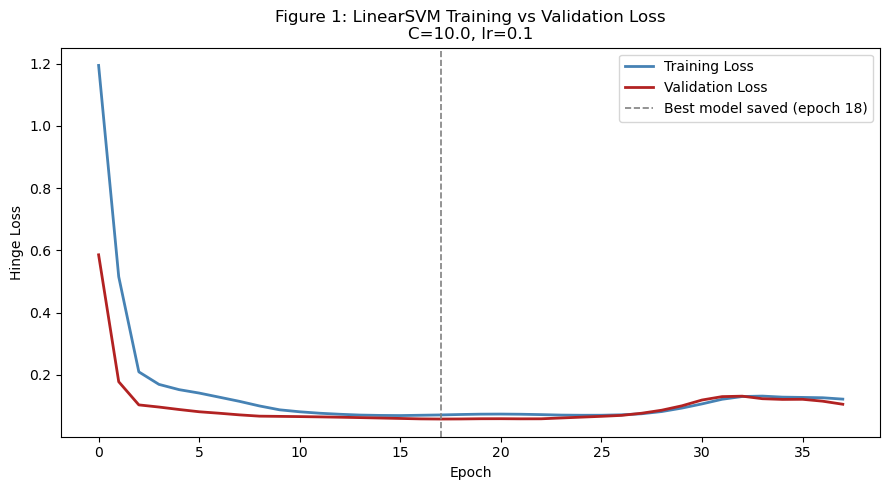

In [6]:
#  FIGURE 1: FINAL MODEL LINEAR SVM LOSS CURVES 
train_losses_svm = np.load('submission_files/svm_train_losses.npy')
val_losses_svm   = np.load('submission_files/svm_val_losses.npy')
best_epoch_svm   = int(np.load('submission_files/svm_best_epoch.npy'))

plt.figure(figsize=(9, 5))
plt.plot(train_losses_svm, label='Training Loss',   color='steelblue', linewidth=2)
plt.plot(val_losses_svm,   label='Validation Loss', color='firebrick',  linewidth=2)
plt.axvline(x=best_epoch_svm,
            color='grey', linestyle='--', linewidth=1.2,
            label=f'Best model saved (epoch {best_epoch_svm + 1})')
plt.xlabel('Epoch')
plt.ylabel('Hinge Loss')
plt.title('Figure 1: LinearSVM Training vs Validation Loss\n'
          'C=10.0, lr=0.1')
plt.legend()
plt.tight_layout()
plt.show()

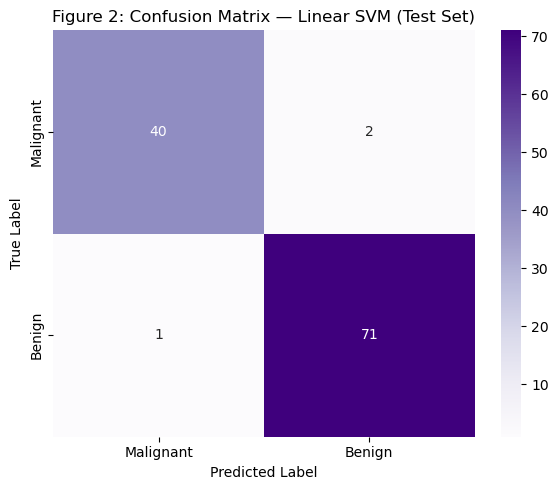

In [9]:
# FIGURE 2: LINEAR SVM CONFUSION MATRIX 
# Load saved weights and evaluate on test set
svm_scaler    = joblib.load('submission_files/svm_scaler.pkl')
X_test        = np.load('submission_files/X_test.npy')
y_test        = np.load('submission_files/y_test.npy')
X_test_scaled = svm_scaler.transform(X_test)
X_test_t      = torch.tensor(X_test_scaled, dtype=torch.float32)

svm_model = LinearSVM(input_dim=30)
svm_model.load_state_dict(torch.load('submission_files/svm_best_weights.pt',
                                      weights_only=True))
svm_model.eval()

with torch.no_grad():
    svm_preds = np.where(svm_model(X_test_t).squeeze().numpy() < 0, 0, 1)

cm = confusion_matrix(y_test, svm_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Figure 2: Confusion Matrix — Linear SVM (Test Set)')
plt.tight_layout()
plt.show()